GOLD PRICE PREDICTION


In [80]:
## IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn  import  metrics
from sklearn.ensemble import RandomForestClassifier
from warnings import filterwarnings
filterwarnings('ignore')


DATA COLLECTION AND PROCESSING

In [81]:
gold=pd.read_csv(r"C:\Users\Isha\Downloads\DA_PROJECTS\ML_PROJECT\GOLD_PRICE_PREDICTION\gld_price_data.csv")

In [82]:
## checking the first 5 rows of the dataset
gold.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [83]:
##checking last 5 rows of the dataset
gold.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [84]:
##checking the shape of the dataset
gold.shape

(2290, 6)

In [85]:
##checking data types of the columns
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [86]:
#checking columns of the dataset
gold.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [87]:
## cheking missing values in the dataset
gold.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [88]:
## checking statistical summary of the dataset
gold.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


CORRELATION

In [89]:

##Checking the correlation between the features of the dataset
corr = gold.select_dtypes(include=np.number).corr()##This selects only the numeric columns (like integers, floats) from the DataFrame.

annot=True → writes the friendship score inside each box.

cmap='coolwarm' → colors the friendships (blue = enemies, red = best friends).

fmt='.1f' → rounds the score neatly.

linewidths=0.3 → draws borders between friendships.

cbar=True → adds a legend explaining the colors.

annot_kws={'size':15} → makes the numbers readable.

<Axes: >

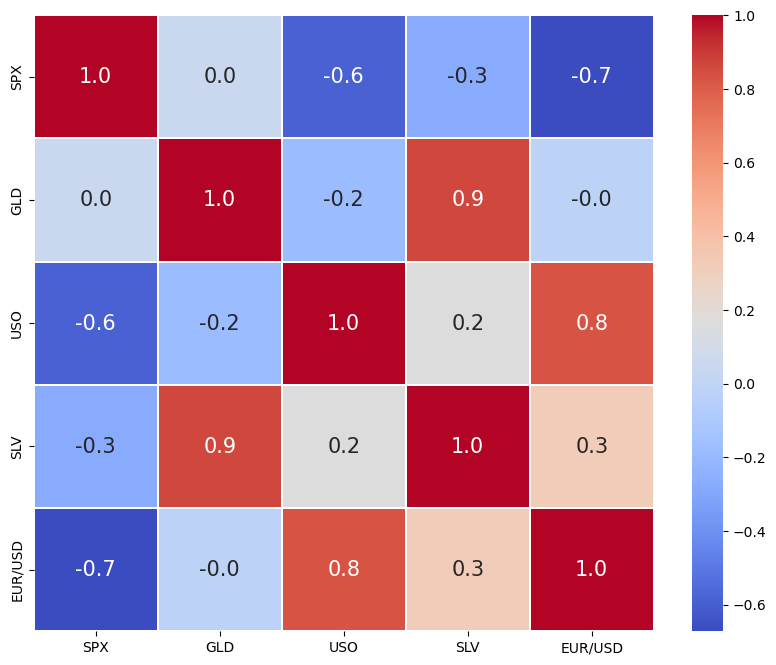

In [90]:
##plotting the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr,annot=True, cmap='coolwarm',fmt='.1f',linewidths=0.3,cbar=True,annot_kws={'size':15})

In [91]:
## correlation values of the features with the target variable 'GLD'
print(corr['GLD'].sort_values(ascending=False))

GLD        1.000000
SLV        0.866632
SPX        0.049345
EUR/USD   -0.024375
USO       -0.186360
Name: GLD, dtype: float64


Text(0, 0.5, 'Frequency')

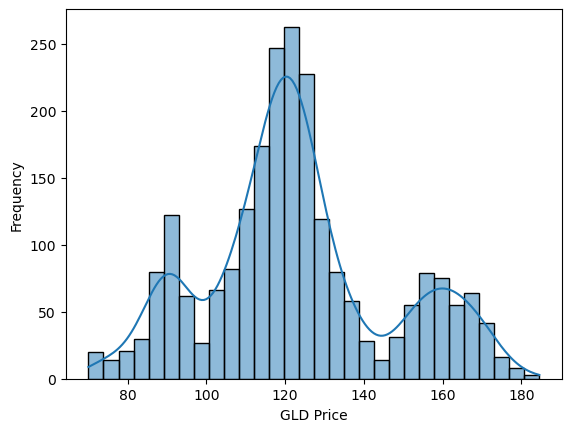

In [92]:
## checking the  distribution of the target variable 'GLD'
sns.histplot(gold['GLD'], kde=True, bins=30)
plt.xlabel('GLD Price')
plt.ylabel('Frequency')
##KDE is a smooth curve that shows the probability distribution of the data.
## Splits the data range into 30 intervals (bins) for the histogram.


SPLITTING THE DATA

In [93]:
## Splitting the dataset into features and target variable
X = gold.drop(['GLD', 'Date'], axis=1)  # Features (all columns except 'GLD')
y = gold['GLD']  # Target variable ('GLD')

In [94]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [95]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


TRAINING AND TESTING DATA

In [96]:
##The dataset is split into training and testing sets using the train_test_split function from scikit-learn. The test size is set to 20% of the data, and a random state is specified for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


MODEL TRAINING RAMDOM FOREST

In [97]:
## MODEL BUILDING
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [100]:
from sklearn.ensemble import RandomForestRegressor

## training the model using the training data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


In [101]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

MODEL EVALUATION

In [103]:
##MODEL EVALUATION
rf_predictions=rf_model.predict(X_test)

In [105]:
##PRinting the value
print(rf_predictions)

[122.46679941 130.28880316 127.70419932  96.69889736 118.97240056
 114.50079901 124.67450149 117.84389959 108.10790103  98.21069968
  95.61129937 167.99879857 149.34040124 116.13570008 170.55530159
  84.96309989 123.23299888 109.29119695 113.14450051 131.563303
 124.27449887 113.57320034 115.97140016 108.77999947 108.75810135
 125.68899929 120.15309974 112.16129943 113.37350151 125.49139916
 146.0725016   89.49199989 167.60339936 113.6085993  108.53440132
 120.03740137 141.96739869 161.38440156 173.95969773 152.9370014
 119.38640093 113.20980076 121.44059937 113.70969947 121.9691377
 108.14450089  89.00129887 114.45169953 129.91440194 118.05950108
 104.45459997 129.91970221 107.13079886 160.90640329 131.64309968
 118.5029995  146.78180036 135.33990244  95.55730104 124.40920156
 114.86129883  86.201401   104.31749892 113.93220076  84.17659911
 122.26760039 116.71309919 113.68990203 165.20290268  92.47060002
  80.27200113 161.06700091 159.14610271 106.78669997 149.17440077
 109.83499725 

 What is R²?
 
 how well your regression model explains the variation in the data.

It ranges between 0 and 1:

0 → model explains nothing (bad fit).

1 → model explains everything (perfect fit).

In [106]:
## r2 score
r2=metrics.r2_score(y_test, rf_predictions)

In [107]:
##printing the r2 score
print("R2 Score:", r2)

R2 Score: 0.9900245384549384


COMPARE ACTUAL VS PREDICTED

In [108]:
#Comparing the actual and predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': rf_predictions})   
print(comparison_df)

          Actual   Predicted
2178  122.320000  122.466799
1271  129.899994  130.288803
1268  126.980003  127.704199
44     96.500000   96.698897
2025  117.580002  118.972401
...          ...         ...
1872  126.680000  123.932600
1075  167.179993  169.144597
299    93.849998   93.639099
306    96.230003   96.371001
1132  154.339996  152.800200

[458 rows x 2 columns]


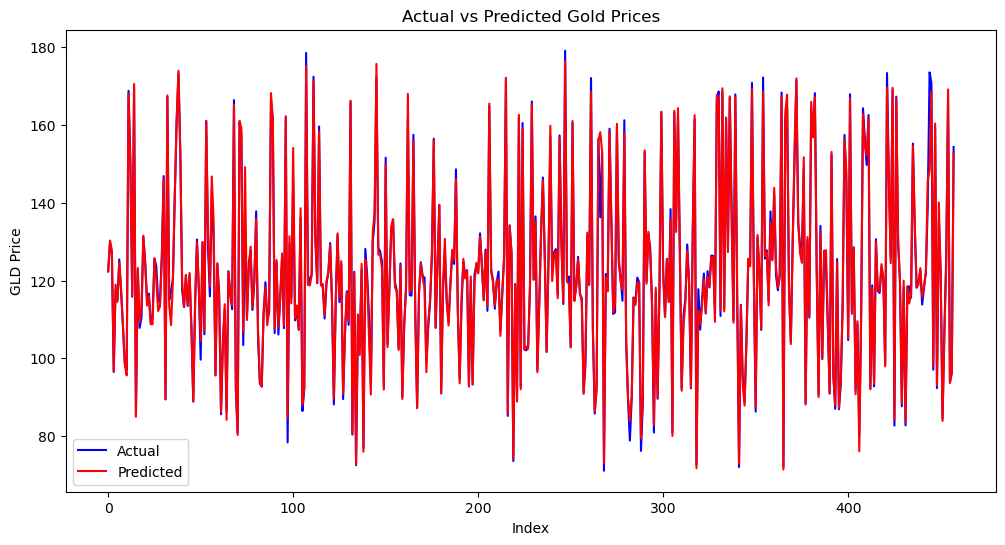

In [109]:
##Comparing the actual and predicted values visually using a line plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(rf_predictions, label='Predicted', color='red')
plt.title('Actual vs Predicted Gold Prices')
plt.xlabel('Index')
plt.ylabel('GLD Price')
plt.legend()
plt.show()

CONCLUSION:


* The Random Forest Regressor model was trained on the gold price dataset and evaluated using the R2 score. 


* The comparison of actual and predicted values shows how well the model performs in predicting gold prices.


* Further tuning and feature engineering may improve the model's accuracy.